In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Debug 
import ipdb
deb = ipdb.set_trace

# General imports
import os
import sys
import yaml
import cortex
import numpy as np
import pandas as pd
import nibabel as nb

# Personal imports
sys.path.append("{}/../../analysis_code/utils".format(os.getcwd()))
from settings_utils import load_settings
from surface_utils import load_surface ,make_surface_image
from pycortex_utils import load_surface_pycortex, set_pycortex_config_file, draw_cortex, get_rois
from cifti_utils import from_91k_to_32k, from_170k_to_59k

In [2]:
# Directories
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'RetinoMaps'

In [3]:
# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)


In [4]:
pycortex_subject = 'sub-hcp1.6mm'
format_ = '170k'
rois_method_format = 'rois-mmp'
rois = ["V1", "V2", "V3", "V3AB", "LO", "VO", "hMT+", "iIPS", "sIPS", "iPCS", "sPCS", "mPCS"]
hemi = 'hemi-R'

In [5]:
roi_verts = get_rois(subject=pycortex_subject, 
                      surf_format=format_, 
                      rois_type=rois_method_format, 
                      mask=True,
                      rois=rois, 
                      hemis=None)

In [9]:
fn = '/Users/uriel/disks/meso_shared/RetinoMaps/derivatives/pp_data/sub-01/170k/rois/sub-01_fmriprep_dct_z-score_rois-mmp.dtseries.nii'


In [10]:
results = load_surface_pycortex(brain_fn=fn)

In [11]:
data_roi = results['data_concat']

In [12]:
img, data = load_surface(fn)

In [24]:
roi = 'V2'
mask2int = roi_verts[roi].astype(int)

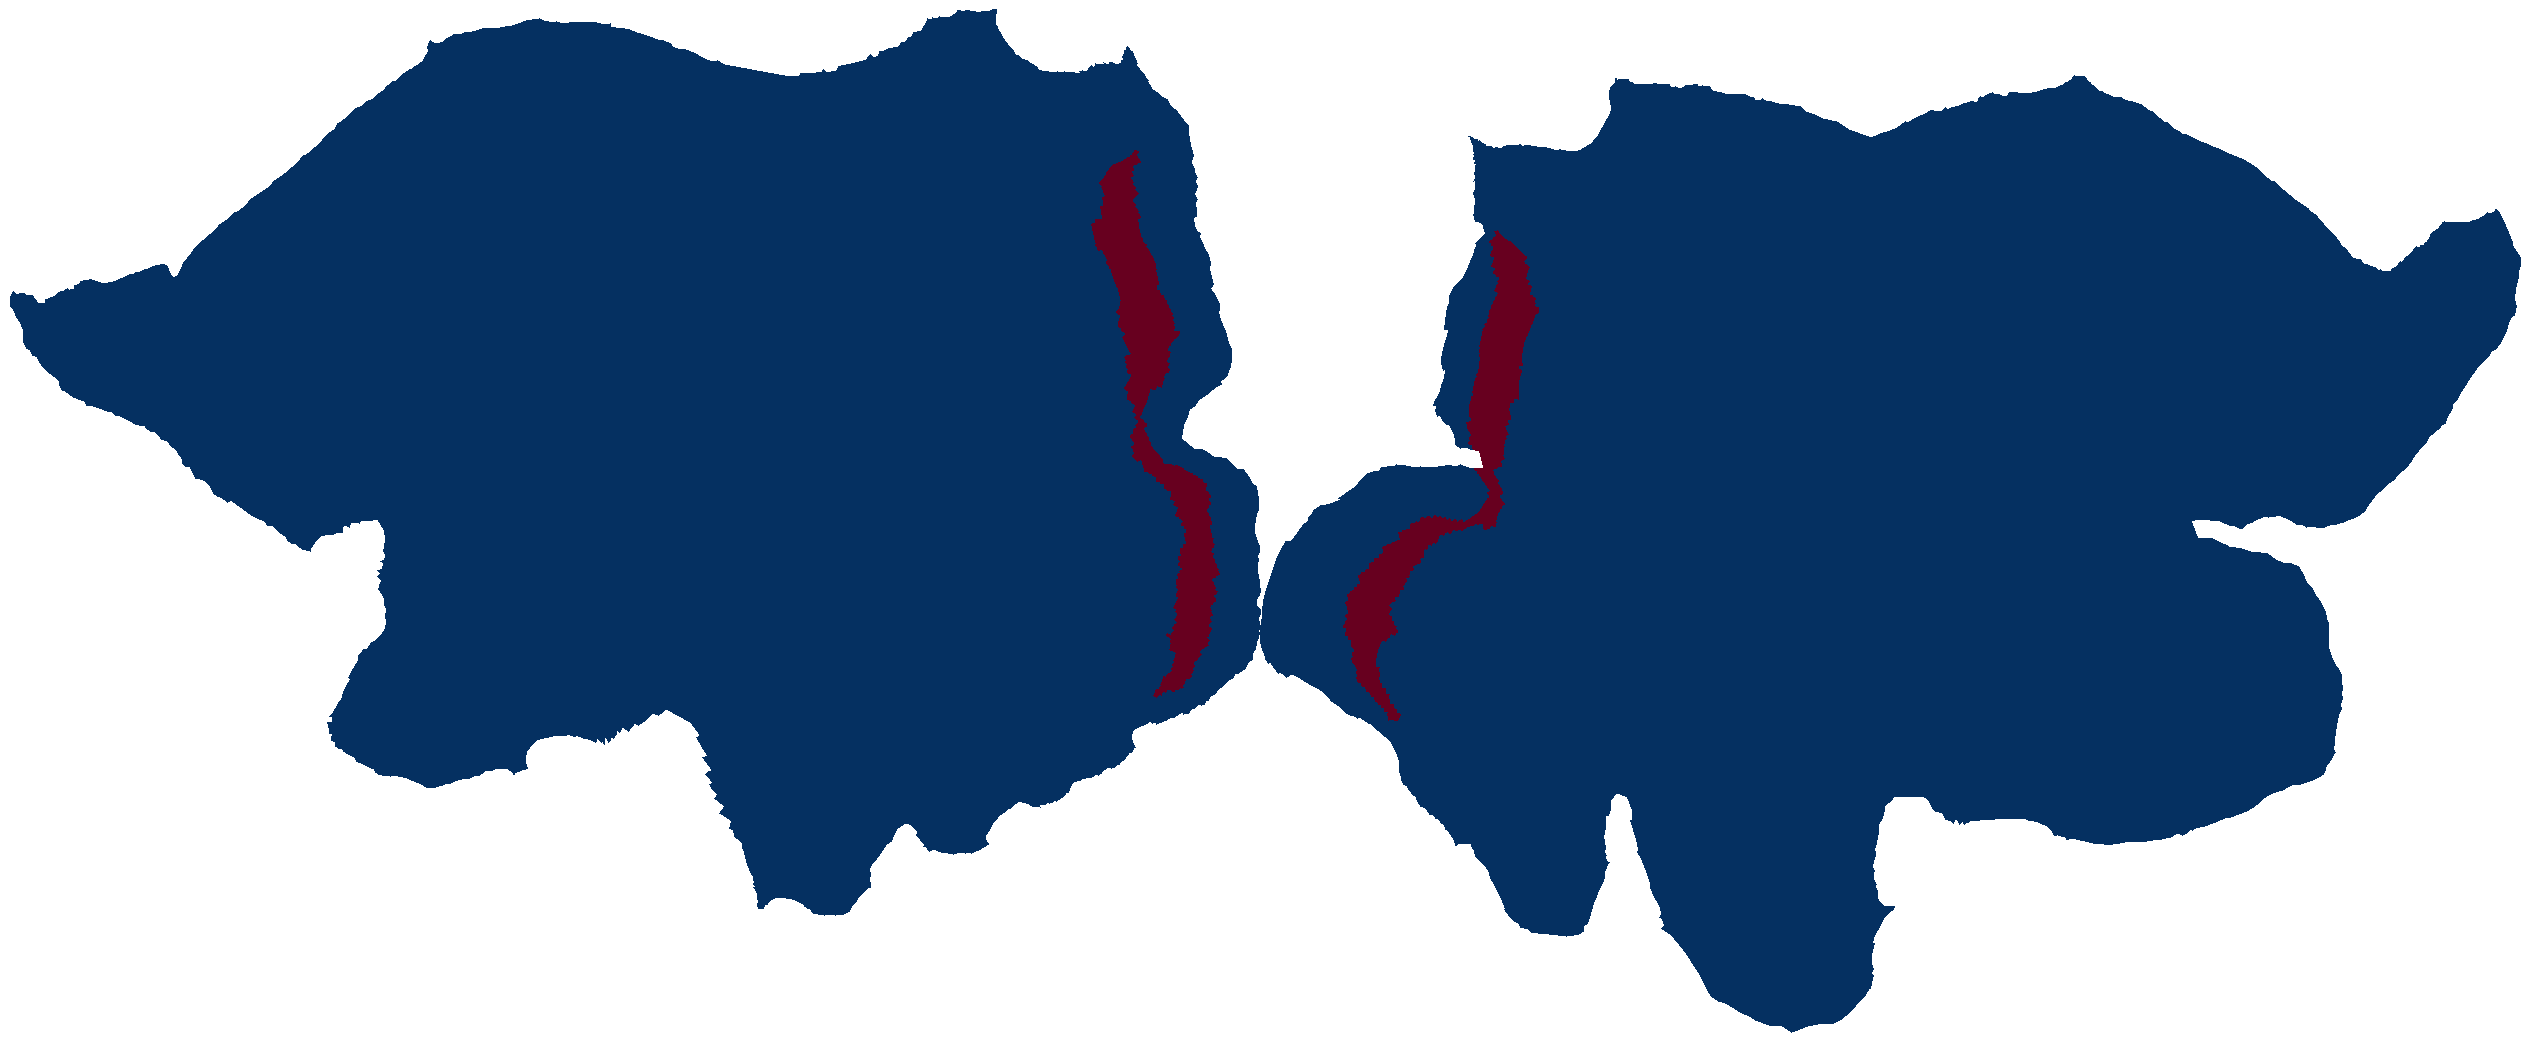

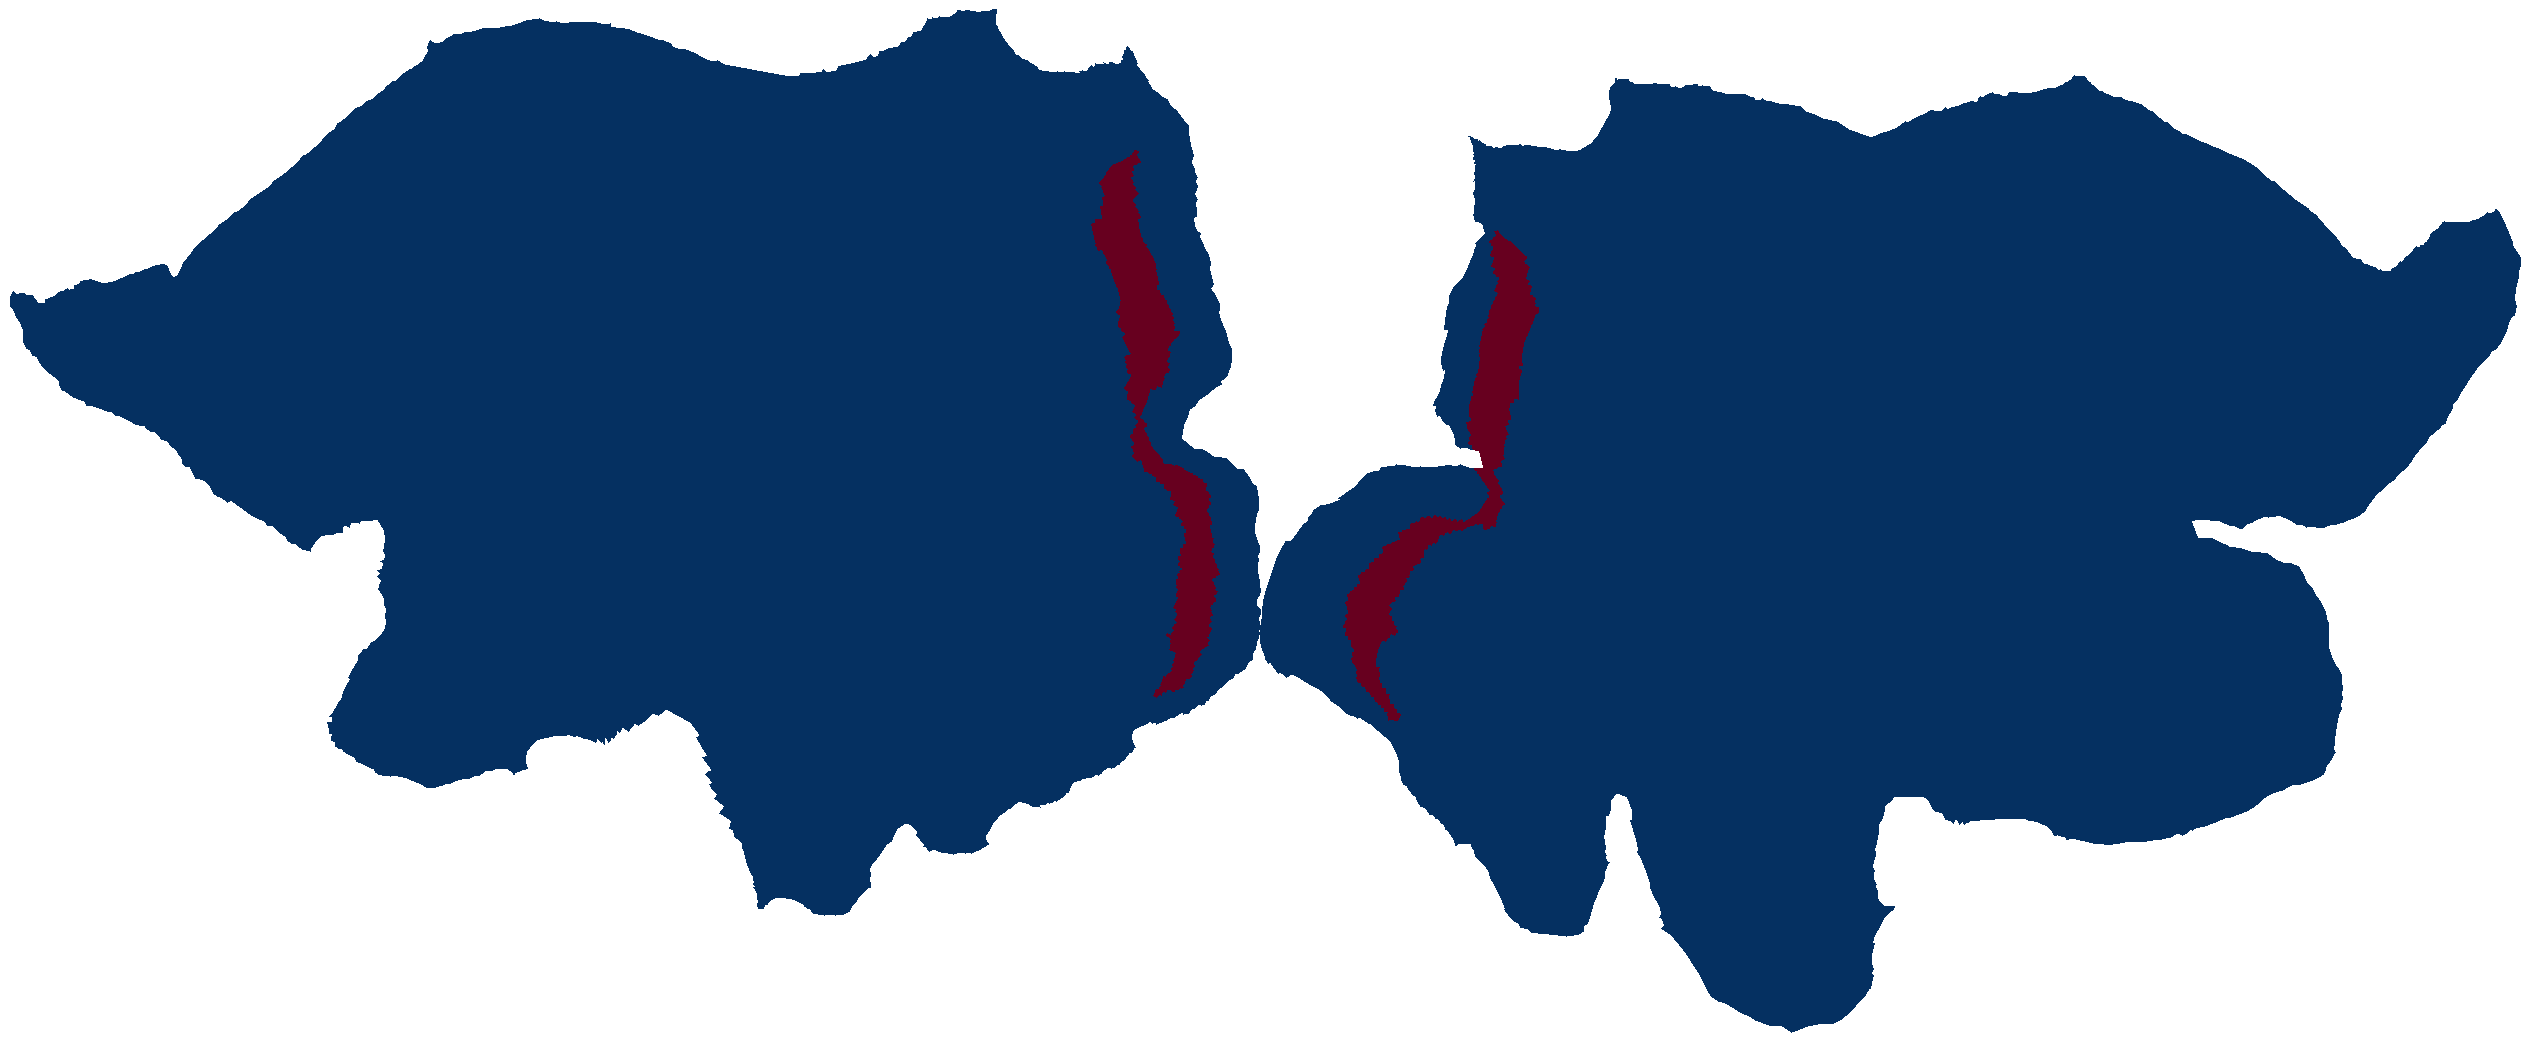

In [25]:
# plot mmp 
vertex_data = cortex.Vertex(mask2int, pycortex_subject)

cortex.quickshow(vertex_data, with_colorbar=False)
# plt.title("MMP atlas", fontsize=25)

# plt.show()

In [6]:
roi = 'V1'
roi_data_170k = roi_verts[roi].astype(int).reshape(1, -1)

In [14]:
roi_img_170k = make_surface_image(data=roi_data_170k, source_img=img, maps_names=['rois'])
nb.save(roi_img_170k, '/Users/uriel/Downloads/mask22.dtseries.nii')

In [20]:
data

memmap([[35., 52., 12., ...,  0.,  0.,  0.]], shape=(1, 170494))